# Biopolymer 3D Printing LCA Pipeline (v3)
This notebook outlines a data pipeline to evaluate and optimize 3D-printed biopolymer construction products. The goal is to connect material recipes, life cycle assessment (LCA), spatial availability of feedstocks, and manufacturing constraints into one decision-support tool.

The pipeline is structured into four main modules:

1. General Morphological Analysis (GMA)  
2. Parameterization  
3. Spatial Analysis  
4. Optimization  

#### Additions in v3
In v3, I created an optimization that takes a fixed biopol recipe and finds the optimal location for it on a map based on material availability. Here are the main changes compared to v2:  
- **GMA (general morphological analysis)**: 
    - I incorporated into the GMA Gabi's biopol recipe (dummy numbers for now), knowing that binders don't change, and there are three options for fillers, but only two fillers can be picked in one go. 
    - This is all implemented in the `BiopolymerRecipeSpace()` class. 
- **pa-LCA (parametric LCA)**: 
    - I created a pa-LCA, `PanelProductionLCA()`, for both the biopol recipe and transportation. 
    - doing the pa-LCA is much more simple than I thought, so now this part is much cleaner than v2. 
    - I also double checked the results on this [google sheet](https://docs.google.com/spreadsheets/d/1Bh_E6Dqw0YfCYrfy3eWVbMnPNf5n63-AkUeF_Qy_eAM/edit?gid=1937135159#gid=1937135159), and they are correct. 
- **Spatial analysis**
    - I created dummy yield maps from the [EU crop map](https://joint-research-centre.ec.europa.eu/jrc-news-and-updates/eu-crop-map-2021-10-18_en) (at 10x10m resolution!) with the class `FeedstockYieldMapBuilder()`
    - Then, I created the class `TravelDistanceCalculator()`, which calculates the transportation distances required to collect a certain required amount of material, based on the yield maps. I used an [integral image](https://www.mathworks.com/help/images/integral-image.html) to make this calculation super fast. 
- **Optimization** 
    - I created the class `AdaptiveFactoryModel()`, which takes in a location (ij index on a raster) and calculates the environmental impact (GWP100) of 3D printing a biopol recipe at that location. 
    - The model is then implemented in a single-objective optimization in `pymoo`
    - I (by "I", I mean chatGPT) also visualized the results, looks pretty cool 😎

#### Aimed additions in next versions:
For the next steps, the main aim is to build towards an algorithm that optimizes **both** for environmental impact **and** structural strength. 
Here are the things I'd like to add in v4 or beyond: 
- **GMA (general morphological analysis)**: 
    - change the strength table (`data/processed/biopol_strength_table.csv`) so it matches the format of testing sample shared by Gabi  
    - re-format the strength table into a 'recipe space', where each recipe is determined by coordinates (x,y), and the strength value is linked to each coordinate. This allows the algorithm to search both the recipe space **and** physical space for the optimal solution, which I think is pretty fucking cool. 
- **pa-LCA (parametric LCA)**: 
    - add other required processes (e.g. energy use for 3D printing) into the pa-LCA 
    - find the correct bw keys / unit impact data for the biopol recipes (perhaps Nils / Stefano / another LCA expert could help here?)
- **Spatial analysis**: 
    - find real spatial maps for the biopol ingredients (soy, seagrass, hemp...etc) and format it to match the current pipeline 
- **Optimization**: 
    - implement dual-objective optimization (environmental impact and strength) 


## 1. General Morphological Analysis

This section defines the design space for biopolymer recipes by combining different bio-based binders and fillers within specified percentage ranges. Instead of using a specialized morphological analysis package, we construct this logic directly in Python for transparency and flexibility.

The process includes three main steps:

1. **Creating input data**  
   Define the percentage ranges for each binder and filler (`biopol_ranges`) and generate all possible one-binder–one-filler combinations (`biopol_combinations`). These form the base design space, where feasibility can later be marked manually.

2. **Assigning dummy strength values**  
   Populate the feasible cells with dummy strength values that increase with both filler percentage and binder number, plus some random variation. This creates an illustrative dataset for later analysis.

Together, these steps generate a structured and parameterized view of all valid biopolymer formulations, forming the foundation for later stages like parameterization and optimization.


### BiopolymerRecipeSpace() class

In [1]:
import itertools
import numpy as np
import pandas as pd
from openpyxl import load_workbook


class BiopolymerRecipeSpace:
    """
    Build the biopolymer recipe option space using General Morphological Analysis (GMA)
    and generate a dummy strength table for all feasible recipes.
    """

    def __init__(
        self,
        input_excel_path: str = "data/dummy_numbers.xlsx",
        ranges_sheet: str = "biopol_ranges",
        combos_sheet: str = "biopol_combinations",
        processed_dir: str = "data/processed",
        strength_step: int = 5,
        random_seed: int | None = None,
    ):
        self.input_excel_path = input_excel_path
        self.ranges_sheet = ranges_sheet
        self.combos_sheet = combos_sheet
        self.processed_dir = processed_dir
        self.strength_step = strength_step

        if random_seed is not None:
            np.random.seed(random_seed)

        self.biopol_ranges: pd.DataFrame | None = None
        self.biopol_combos: pd.DataFrame | None = None
        self.strength_table: pd.DataFrame | None = None

    # ------------------------
    # 1. Load ranges from Excel
    # ------------------------
    def load_ranges(self) -> pd.DataFrame:
        self.biopol_ranges = pd.read_excel(
            self.input_excel_path,
            sheet_name=self.ranges_sheet
        )
        return self.biopol_ranges

    # ---------------------------------
    # 2. Build filler/binder combinations
    # ---------------------------------
    def build_combinations(
        self,
        binder_1: str = "pea_protein",
        binder_2: str = "xanthan_gum",
    ) -> pd.DataFrame:
        if self.biopol_ranges is None:
            self.load_ranges()

        # select only fillers
        fillers_df = self.biopol_ranges[
            self.biopol_ranges["parameter"] == "filler"
        ][["id", "option"]].copy()

        # ---- two-filler combinations ----
        pairs = list(itertools.combinations(fillers_df.itertuples(index=False), 2))
        rows = []
        for f1, f2 in pairs:
            rows.append(
                {
                    "id": f"{f1.id}_{f2.id}",
                    "filler_1": f1.option,
                    "filler_2": f2.option,
                    "feasible": True,
                }
            )

        # ---- single-filler combos (filler + none) ----
        for f in fillers_df.itertuples(index=False):
            rows.append(
                {
                    "id": f"{f.id}_none",
                    "filler_1": f.option,
                    "filler_2": "none",
                    "feasible": True,
                }
            )

        biopol_combos = pd.DataFrame(rows)
        biopol_combos["binder_1"] = binder_1
        biopol_combos["binder_2"] = binder_2
        biopol_combos = biopol_combos[
            ["id", "binder_1", "binder_2", "filler_1", "filler_2", "feasible"]
        ]

        self.biopol_combos = biopol_combos
        return biopol_combos

    # -----------------------------------------
    # 3. Save combinations back into the Excel
    # -----------------------------------------
    def write_combinations_to_excel(self) -> None:
        if self.biopol_combos is None:
            raise ValueError("biopol_combos is None. Run build_combinations() first.")

        # ensure workbook exists
        _ = load_workbook(self.input_excel_path)

        with pd.ExcelWriter(
            self.input_excel_path,
            engine="openpyxl",
            mode="a",
            if_sheet_exists="replace",
        ) as writer:
            self.biopol_combos.to_excel(
                writer,
                sheet_name=self.combos_sheet,
                index=False,
            )

    # ---------------------------------------
    # 4. Export ranges & combinations as CSVs
    # ---------------------------------------
    def export_ranges_and_combos_csv(self) -> None:
        if self.biopol_ranges is None:
            raise ValueError("biopol_ranges is None. Run load_ranges() first.")
        if self.biopol_combos is None:
            raise ValueError("biopol_combos is None. Run build_combinations() first.")

        ranges_path = f"{self.processed_dir}/biopol_ranges.csv"
        combos_path = f"{self.processed_dir}/biopol_combinations.csv"

        self.biopol_ranges.to_csv(ranges_path, index=False)
        print(f"biopol_ranges saved as csv -> {ranges_path}")
        self.biopol_combos.to_csv(combos_path, index=False)
        print(f"biopol_combinations saved as csv -> {combos_path}")

    # ------------------------------
    # 5. Build strength table (dummy)
    # ------------------------------
    def build_strength_table(
        self,
        binder_1: str = "soy_protein",
        binder_2: str = "xanthan_gum",
    ) -> pd.DataFrame:
        if self.biopol_ranges is None:
            self.load_ranges()

        step = self.strength_step
        rows = []

        # copy to avoid SettingWithCopyWarning
        filler_ranges = self.biopol_ranges[
            self.biopol_ranges["parameter"] == "filler"
        ].copy()

        filler_ranges['range_high'] = filler_ranges.range_high.astype('int')
        filler_ranges['range_low'] = filler_ranges.range_low.astype('int')

        # ----- 1. Single-filler recipes -----
        for r in filler_ranges.itertuples(index=False):
            for pc1 in range(r.range_low, r.range_high + step, step):
                rows.append(
                    {
                        "filler_1": r.option,
                        "filler_1_pc": pc1,
                        "filler_2": "none",
                        "filler_2_pc": 0,
                        "strength": 0.0,  # dummy placeholder
                    }
                )

        # ----- 2. Two-filler recipes -----
        for f1, f2 in itertools.combinations(filler_ranges.itertuples(index=False), 2):
            for pc1 in range(f1.range_low, f1.range_high + step, step):
                for pc2 in range(f2.range_low, f2.range_high + step, step):
                    rows.append(
                        {
                            "filler_1": f1.option,
                            "filler_1_pc": pc1,
                            "filler_2": f2.option,
                            "filler_2_pc": pc2,
                            "strength": 0.0,  # dummy placeholder
                        }
                    )

        strength_table = pd.DataFrame(rows)

        # keep only recipes where total filler percentage <= 100
        strength_table = strength_table.query("filler_1_pc + filler_2_pc <= 100")

        # assign dummy strengths uniformly between 1 and 100
        strength_table["strength"] = np.random.randint(
            1, 101, size=len(strength_table)
        )

        # Split the remaining % evenly between the two binders
        remaining_pct = 100 - strength_table["filler_1_pc"] - strength_table["filler_2_pc"]

        strength_table["binder_1_pc"] = remaining_pct / 2
        strength_table["binder_1"] = binder_1
        strength_table["binder_2_pc"] = remaining_pct / 2
        strength_table["binder_2"] = binder_2

        strength_table = strength_table[
            [
                "binder_1",
                "binder_1_pc",
                "binder_2",
                "binder_2_pc",
                "filler_1",
                "filler_1_pc",
                "filler_2",
                "filler_2_pc",
                "strength",
            ]
        ]

        self.strength_table = strength_table
        return strength_table

    # ------------------------------
    # 6. Export strength table to CSV
    # ------------------------------
    def export_strength_table_csv(self, filename: str = "biopol_strength_table.csv") -> None:
        if self.strength_table is None:
            raise ValueError("strength_table is None. Run build_strength_table() first.")

        path = f"{self.processed_dir}/{filename}"
        self.strength_table.to_csv(path, index=False)
        print(f"strength_table saved as csv -> {path}")

    # ------------------------------
    # 7. Convenience: run the full pipeline
    # ------------------------------
    def run_all(self) -> None:
        """
        Run the whole GMA pipeline:
        - load ranges
        - build combinations
        - write combinations back to Excel
        - export ranges & combos to CSV
        - build strength table with dummy values
        - export strength table to CSV
        """
        self.load_ranges()
        self.build_combinations()
        self.write_combinations_to_excel()
        self.export_ranges_and_combos_csv()
        self.build_strength_table()
        self.export_strength_table_csv()


#### Implementation

In [2]:
gma = BiopolymerRecipeSpace(
    input_excel_path="data/dummy_numbers.xlsx",
    processed_dir="data/processed",
    strength_step=5,
    random_seed=42,  # for reproducible dummy strengths
)

# Run full pipeline
gma.run_all()

biopol_ranges saved as csv -> data/processed/biopol_ranges.csv
biopol_combinations saved as csv -> data/processed/biopol_combinations.csv
strength_table saved as csv -> data/processed/biopol_strength_table.csv


## 2. Parameterized LCA (pa-LCA)
- link ecoinvent data to all possible options using brightway keys 
- parameterize options into hierarchical structure of process, sub-process, and sub-sub-process 
- pre-calculate environmental impact of all parameterized options 

### PanelProductionLCA() class

In [3]:
import os

from lcpy.calculators.helpers import ExchangeHolder, ImpactCalculator, ImpactHandler
from lcpy.calculators.bw_int import mpLCAer
from lcpy.hvs.hvs import (
    create_dataframe_dict,
    save_dataframes_to_excel,
    create_name_dictionaries,
)
from lcpy.hvs.map_dicts import create_mapping, create_list_with_unique_activities

# -------------------------------------------------------------------
# Default configuration (you can move / override this as you like)
# -------------------------------------------------------------------

DEFAULT_METHODS_LIST = [
    ('TRACI v2.1', 'acidification', 'acidification potential (AP)'),
    ('TRACI v2.1', 'climate change', 'global warming potential (GWP100)'),
    ('TRACI v2.1', 'ecotoxicity: freshwater', 'ecotoxicity: freshwater'),
    ('TRACI v2.1', 'eutrophication', 'eutrophication potential'),
    ('TRACI v2.1', 'human toxicity: carcinogenic', 'human toxicity: carcinogenic'),
    ('TRACI v2.1', 'human toxicity: non-carcinogenic', 'human toxicity: non-carcinogenic'),
    ('TRACI v2.1', 'ozone depletion', 'ozone depletion potential (ODP)'),
    ('TRACI v2.1', 'particulate matter formation', 'particulate matter formation potential (PMFP)'),
    ('TRACI v2.1', 'photochemical oxidant formation', 'maximum incremental reactivity (MIR)'),
]

DEFAULT_METHOD_UNITS = [
    'kg SO2-Eq',
    'kg CO2-Eq',
    'CTUe',
    'kg N-Eq',
    'CTUh',
    'CTUh',
    'kg CFC-11-Eq',
    'kg PM2.5-Eq',
    'kg O3-Eq',
]

DEFAULT_IMPACT_CATEGORY_SHORTNAMES = [
    'AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR'
]

DEFAULT_BW_CONFIG = {
    "path_to_brightway_project": (
        "/Users/tsuitpy/Library/Application Support/Brightway3/"
        "biopol_lca.967046090aaaeb21fcd35d8654c4df5a"
    ),
    "bw_project": "biopol_lca",
    "bw_database": "biopol_lca_database",
    "bw_biosphere": "ecoinvent-3.9.1-biosphere",
    "bw_ecoinvent": "ecoinvent-3.9.1-cutoff",
}


class PanelProductionLCA:
    """
    Parameterized LCA for 3D-printed biopolymer panel production.

    - Initializes Brightway + mpLCAer once (heavy).
    - Precomputes activity-level unit impacts.
    - `evaluate(...)` takes recipe fractions + transport intensity and
      returns impact DataFrames (and optionally saves to Excel).
    """

    def __init__(
        self,
        brightway_config: dict = None,
        methods_list=None,
        impact_category_names=None,
        impact_category_units=None,
        target_dir: str = "results/lca",
        base_name: str = "panelProduction",
    ):
        # ---- configuration ----
        self.bw_config = brightway_config or DEFAULT_BW_CONFIG
        self.methods_list = methods_list or DEFAULT_METHODS_LIST
        self.impact_category_names = impact_category_names or DEFAULT_IMPACT_CATEGORY_SHORTNAMES
        self.impact_category_units = impact_category_units or DEFAULT_METHOD_UNITS

        self.target_dir = target_dir
        self.base_name = base_name
        os.makedirs(self.target_dir, exist_ok=True)

        # ---- static activity keys (don't depend on recipe) ----
        # sub-sub-processes: ingredients / fillers
        self.keys_biopol_production = {
            'b1_pea_protein': '8ce68e5f71f8f8c5dc50edb913e9cea1',  # potato starch market
            'b2_xanthan_gum': '9ef63345ae414b0aa5683f09f4d0b806',  # anionic resin market
            'f1_bark': 'd82e94ec45e662362de31d0ac344dc51',        # wood wool market
            'f2_seagrass': 'b8b0f0ca4e8e1a99ddae3f6ae610be2e',     # sunn hemp plant, harvested
            'f3_hemp': '94c1cb9e760faf73987ffea6c08cfcf1',         # coconut husk market
        }

        # sub-process: transport
        self.keys_transportation = {
            'transportation': '9f5ff656ecdc15acd23085211786936f',
        }

        # main process: panel production (biopol + transport)
        self.keys_panel_production = {
            'biopol_production': '',
            'transportation': '',
        }
        self.main_process_names = ['panel production']

        # precompute things that don't depend on recipe
        self._setup_lca_backend()

    # ------------------------------------------------------------------
    # Internal setup: Brightway + mpLCAer + static mappings
    # ------------------------------------------------------------------
    def _setup_lca_backend(self):
        # Link sub-processes for mapping (binder/filler + transport)
        key_list_sub_processes = [self.keys_biopol_production, self.keys_transportation]

        # mapping from main process to sub-sub-process activities
        self.mapping_names = create_mapping(self.keys_panel_production, key_list_sub_processes)

        # list of unique underlying activities (for mpLCAer)
        self.unique_activities = create_list_with_unique_activities(key_list_sub_processes)

        # Name dictionaries for outputs
        self.names_dictionary = create_name_dictionaries(self.mapping_names, key_list_sub_processes)
        self.names_dictionary_graphite_main = {
            self.main_process_names[0]: list(self.names_dictionary.keys())
        }

        # Run mpLCAer once to get unit impacts for all involved activities
        self.lca_engine = mpLCAer(
            4,
            self.methods_list,
            self.bw_config,
        )
        self.lca_engine.import_isolated_environment()
        self.lca_engine.lca_calculations(self.mapping_names)

    # ------------------------------------------------------------------
    # Public API: evaluate a given recipe + transport intensity
    # ------------------------------------------------------------------
    def evaluate(
        self,
        b1_pea_protein: float,
        b2_xanthan_gum: float,
        f1_bark: float,
        f2_seagrass: float,
        f3_hemp: float,
        transport_ton_km_per_kg: float = 10.0,
        save_excel: bool = True,
    ):
        """
        Evaluate panel production LCA for a given recipe and transport intensity.

        All ingredient inputs are in mass units (e.g. kg) and will be normalized
        to fractions of total biopol mass.

        Parameters
        ----------
        b1_pea_protein, b2_xanthan_gum, f1_bark, f2_seagrass, f3_hemp : float
            Mass contributions of each ingredient in the biopol mixture.
        transport_ton_km_per_kg : float
            Transport intensity per kg of wall panel [ton-km / kg panel].
        save_excel : bool
            If True, write contribution and absolute results to Excel files.

        Returns
        -------
        results : dict
            {
              "contributions": dict(sheet_name -> df),
              "absolute": dict(sheet_name -> df),
              "panel_impacts": df for main process only
            }
        """
        # ---- 1. Build normalized recipe ----
        biopol_mass = (
            b1_pea_protein
            + b2_xanthan_gum
            + f1_bark
            + f2_seagrass
            + f3_hemp
        )
        if biopol_mass <= 0:
            raise ValueError("Total biopol mass must be > 0.")

        biopol_production_exchanges_amounts = [
            b1_pea_protein / biopol_mass,
            b2_xanthan_gum / biopol_mass,
            f1_bark / biopol_mass,
            f2_seagrass / biopol_mass,
            f3_hemp / biopol_mass,
        ]

        # transport sub-process (kept as 1: 1 unit of transport process per unit of transport intensity)
        transportation_exchanges_amounts = [1.0]

        # main process: 1 kg biopol per kg panel, plus transport intensity per kg panel
        panel_production_exchanges_amounts = [
            1.0,                      # kg biopol per kg wall panel
            transport_ton_km_per_kg,  # ton-km transport per kg wall panel
        ]

        # ---- 2. Mapping exchanges for sub-processes and main process ----
        key_list_sub_processes = [self.keys_biopol_production, self.keys_transportation]

        # sub-process exchanges: sub-sub-processes -> sub-processes
        mapping_exchanges = create_mapping(
            self.keys_panel_production,
            [biopol_production_exchanges_amounts, transportation_exchanges_amounts],
        )

        # main-process exchanges: sub-processes -> main process
        mapping_exchanges_mp = {
            self.main_process_names[0]: panel_production_exchanges_amounts
        }

        # ------------------------------------------------------------------
        # 3. Sub-process LCA (biopol production + transport unit impacts)
        # ------------------------------------------------------------------
        sp_exchange_manager = ExchangeHolder(self.methods_list)
        sp_exchange_manager.create_exchange_arrays(mapping_exchanges)

        sp_impact_calculator = ImpactCalculator()
        sp_impact_calculator.impact_calculation_simple(
            self.lca_engine.unit_impacts,
            sp_exchange_manager.exchanges_dict,
        )

        sp_results_handler = ImpactHandler(self.impact_category_names)
        sp_results_handler.create_dataframes(
            sp_impact_calculator.simple_impacts,
            self.names_dictionary,
        )

        # scale to total unit impact at sub-process level
        mp_results_handler = ImpactHandler(self.impact_category_names)
        mp_results_handler.calculate_total_unit_impact(
            sp_results_handler.total_impact_arrays,
            self.main_process_names[0],
        )

        # ------------------------------------------------------------------
        # 4. Main-process LCA (panel production recipe)
        # ------------------------------------------------------------------
        mp_exchange_manager = ExchangeHolder(self.methods_list)
        mp_exchange_manager.create_exchange_arrays(mapping_exchanges_mp)

        mp_impact_calculator = ImpactCalculator()
        mp_impact_calculator.impact_calculation_simple(
            mp_results_handler.total_unit_impact,
            mp_exchange_manager.exchanges_dict,
        )

        mp_results_handler.create_dataframes(
            mp_impact_calculator.simple_impacts,
            self.names_dictionary_graphite_main,
        )

        # ------------------------------------------------------------------
        # 5. Summarize results (sub-process + main process)
        # ------------------------------------------------------------------
        # contribution analysis
        df_list_results = list(sp_results_handler.df_contributions.values())
        df_list_results.append(mp_results_handler.df_contributions[self.main_process_names[0]])

        sheet_names = list(self.keys_panel_production.keys()) + ['Total']
        dict_with_contribution_dfs = create_dataframe_dict(df_list_results, sheet_names)

        # absolute results
        list_with_absolute_results = list(sp_results_handler.df_impacts.values())
        list_with_absolute_results.append(mp_results_handler.df_impacts[self.main_process_names[0]])
        dict_with_absolute_results_df = create_dataframe_dict(
            list_with_absolute_results, sheet_names
        )

        # optional: save to Excel
        if save_excel:
            excel_file_path_contribution_results = os.path.join(
                self.target_dir, f"{self.base_name}_contribution.xlsx"
            )
            excel_file_path_absolute_results = os.path.join(
                self.target_dir, f"{self.base_name}_absoluteResults.xlsx"
            )
            save_dataframes_to_excel(
                dict_with_contribution_dfs,
                excel_file_path_contribution_results,
            )
            save_dataframes_to_excel(
                dict_with_absolute_results_df,
                excel_file_path_absolute_results,
            )

        return {
            "contributions": dict_with_contribution_dfs,
            "absolute": dict_with_absolute_results_df,
            "panel_impacts": mp_results_handler.df_impacts[self.main_process_names[0]],
        }


#### Implementation

In [4]:
# initiate pa-LCA object outside of optimization (takes ~30 seconds)
lca = PanelProductionLCA()

# somewhere inside your objective:
result = lca.evaluate(
    b1_pea_protein=40,
    b2_xanthan_gum=0,
    f1_bark=60,
    f2_seagrass=0,
    f3_hemp=0,
    transport_ton_km_per_kg=10,
    save_excel=False,  # probably False inside optimization
)

panel_impacts_df = result["panel_impacts"]
# e.g. your objective = panel_impacts_df.loc["panel production", "GWP100"] or similar

## 3. Spatial Analysis

We created a set of spatial datasets for analysis:

1. **Crop Yield Map (`data/processed/EU_crop_map_yield.tif`)**  
   Generated from a small sample of the EU Crop Map using dummy data on crop types and their annual yields to estimate yield per pixel.

These datasets together form the foundation for spatial analysis of crop production and potential factory siting.



### FeedstockYieldMapBuilder()

In [5]:
import random
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt


class FeedstockYieldMapBuilder:
    """
    Build a 3-band feedstock yield raster from an EU crop map and a biopol_ranges table.

    Steps:
    1. Sample a random window from a large crop map with enough variation.
    2. Analyze the sample to find dominant crop codes.
    3. Assign dummy yields to those codes and map them onto biopol_ranges.
    4. Create a 3-band raster: [crop_code, yield_kg_m2_year, yield_kg_pixel_year].
    """

    def __init__(
        self,
        crop_raster_path: str = "data/EU_crop_map.tif",
        sample_raster_path: str = "data/EU_crop_map_sample.tif",
        biopol_ranges_csv: str = "data/processed/biopol_ranges.csv",
        out_biopol_feedstocks_csv: str = "data/processed/bipol_ranges_with_feedstocks.csv",
        out_yield_raster_path: str = "data/processed/EU_crop_map_yield.tif",
        window_size: int = 2000,
        max_attempts: int = 20,
        n_top_codes: int = 5,
        random_seed: int | None = None,
    ):
        self.crop_raster_path = crop_raster_path
        self.sample_raster_path = sample_raster_path
        self.biopol_ranges_csv = biopol_ranges_csv
        self.out_biopol_feedstocks_csv = out_biopol_feedstocks_csv
        self.out_yield_raster_path = out_yield_raster_path
        self.window_size = window_size
        self.max_attempts = max_attempts
        self.n_top_codes = n_top_codes

        if random_seed is not None:
            random.seed(random_seed)
            np.random.seed(random_seed)

        # internal state
        self.sample_window = None
        self.sample_arr = None
        self.pixel_area_m2 = None
        self.top_codes = None
        self.dummy_yield_dict = None
        self.biopol_df = None

    # =========================
    # 1. Sample crop map window
    # =========================

    def create_sample_window(self, visualize: bool = True) -> None:
        """Find a random window with variation and save as a small GeoTIFF."""
        with rasterio.open(self.crop_raster_path) as src:
            width, height = src.width, src.height
            print(f"Raster size: {width} × {height}")

            window, arr = self._find_random_window_with_variation(src)
            self.sample_window = window
            self.sample_arr = arr

            if visualize:
                self._plot_sample(arr)

            self._save_sample_tif(src, window, arr)

        print(f"💾 Saved cropped GeoTIFF to: {self.sample_raster_path}")

    def _find_random_window_with_variation(self, src: rasterio.io.DatasetReader):
        """Try random windows until one with more than one unique value is found."""
        found = False
        attempts = 0
        wsize = self.window_size

        width, height = src.width, src.height

        while not found and attempts < self.max_attempts:
            col_off = random.randint(0, width - wsize)
            row_off = random.randint(0, height - wsize)
            window = Window(col_off, row_off, wsize, wsize)

            data_small = src.read(1, window=window)
            unique_vals = np.unique(data_small)

            if len(unique_vals) > 1:
                found = True
                print(f"✅ Found mixed area at offset ({col_off}, {row_off})")
                print(f"Unique crop codes (first 10): {unique_vals[:10]}")
                return window, data_small

            attempts += 1

        raise ValueError("⚠️ No variation found — try another tile or increase max_attempts.")

    def _plot_sample(self, data_small: np.ndarray) -> None:
        """Visualize the sampled window."""
        plt.figure(figsize=(8, 8))
        plt.imshow(data_small, cmap="tab20", interpolation="nearest")
        plt.title("EUCROPMAP sample window")
        plt.axis("off")
        plt.show()

    def _save_sample_tif(
        self,
        src: rasterio.io.DatasetReader,
        window: Window,
        data_small: np.ndarray,
    ) -> None:
        """Save the sampled window to a new GeoTIFF."""
        transform = src.window_transform(window)
        profile = src.profile
        profile.update(
            {
                "height": self.window_size,
                "width": self.window_size,
                "transform": transform,
            }
        )

        with rasterio.open(self.sample_raster_path, "w", **profile) as dst:
            dst.write(data_small, 1)

    # =====================================
    # 2. Analyze sample and assign yields
    # =====================================

    def analyze_sample_and_assign_yields(self) -> None:
        """
        - Read the sample raster,
        - find top crop codes by area,
        - generate dummy yields,
        - assign codes + yields into biopol_ranges.
        """
        arr, pixel_area_m2 = self._read_sample_raster()
        self.pixel_area_m2 = pixel_area_m2

        top_codes = self._find_top_crop_codes(arr, pixel_area_m2)
        self.top_codes = top_codes

        dummy_yield_dict = self._build_dummy_yields(top_codes)
        self.dummy_yield_dict = dummy_yield_dict

        df = self._assign_codes_and_yields_to_biopol(dummy_yield_dict, top_codes)
        self.biopol_df = df

        df.to_csv(self.out_biopol_feedstocks_csv, index=False)
        print(f"\n✅ Wrote updated table with feedstocks to {self.out_biopol_feedstocks_csv}\n")

    def _read_sample_raster(self):
        """Read sample raster and compute pixel area."""
        with rasterio.open(self.sample_raster_path) as src:
            arr = src.read(1)
            res_x, res_y = src.res  # assumes 10m x 10m
            pixel_area_m2 = res_x * res_y
        return arr, pixel_area_m2

    def _find_top_crop_codes(self, arr: np.ndarray, pixel_area_m2: float):
        """Compute top crop codes by area (ignoring 0)."""
        vals, counts = np.unique(arr, return_counts=True)
        areas_m2 = counts * pixel_area_m2
        code_area_pairs = list(zip(vals, areas_m2))
        code_area_pairs = [p for p in code_area_pairs if p[0] != 0]
        code_area_pairs.sort(key=lambda x: x[1], reverse=True)

        top_codes = [code for code, area in code_area_pairs[: self.n_top_codes]]
        print(f"Top {len(top_codes)} codes by area:", top_codes)
        return top_codes

    def _build_dummy_yields(self, top_codes: list[int]) -> dict[int, float]:
        """
        Build dummy yields for top codes.
        Example: decreasing gradient from 2.5 to 1.0 kg/m²/year.
        """
        base_yields = np.linspace(2.5, 1.0, num=len(top_codes))
        dummy_yield_dict = {code: float(y) for code, y in zip(top_codes, base_yields)}
        return dummy_yield_dict

    def _assign_codes_and_yields_to_biopol(
        self,
        dummy_yield_dict: dict[int, float],
        top_codes: list[int],
    ) -> pd.DataFrame:
        """
        Load biopol_ranges.csv and assign crop codes + yields to binders/fillers
        in an alternating order: b1, f1, b2, f2, ...
        """
        df = pd.read_csv(self.biopol_ranges_csv)

        binders = df[df["parameter"].str.lower() == "binder"].sort_values("id").copy()
        fillers = df[df["parameter"].str.lower() == "filler"].sort_values("id").copy()

        weaved_rows = self._weave_binders_and_fillers_indices(binders, fillers)

        assignable_count = min(len(weaved_rows), len(top_codes))

        df["eu_crop_code"] = np.nan
        df["yield_kg_m2"] = np.nan

        for i in range(assignable_count):
            row_idx = weaved_rows[i]
            crop_code = top_codes[i]
            df.loc[row_idx, "eu_crop_code"] = crop_code
            df.loc[row_idx, "yield_kg_m2"] = dummy_yield_dict[crop_code]

        # store crop codes as nullable integer
        df["eu_crop_code"] = df["eu_crop_code"].astype("Int64")
        return df

    def _weave_binders_and_fillers_indices(
        self,
        binders: pd.DataFrame,
        fillers: pd.DataFrame,
    ) -> list[int]:
        """Create index order [b1, f1, b2, f2, ...] + extras."""
        binder_idx = binders.index.tolist()
        filler_idx = fillers.index.tolist()

        weaved_rows: list[int] = []
        for b_row, f_row in zip(binder_idx, filler_idx):
            weaved_rows.append(b_row)
            weaved_rows.append(f_row)

        extra_binders = binder_idx[len(filler_idx) :]
        extra_fillers = filler_idx[len(binder_idx) :]
        weaved_rows.extend(extra_binders)
        weaved_rows.extend(extra_fillers)

        return weaved_rows

    # =======================================
    # 3. Build 3-band yield raster
    # =======================================

    def build_yield_raster(self) -> None:
        """
        Create a 3-band raster:
        Band 1: crop_code
        Band 2: yield_kg_m2_year
        Band 3: yield_kg_pixel_year
        """
        if self.biopol_df is None:
            raise ValueError("biopol_df is None. Run analyze_sample_and_assign_yields() first.")
        if self.pixel_area_m2 is None:
            raise ValueError("pixel_area_m2 is None. Run analyze_sample_and_assign_yields() first.")

        df = self.biopol_df
        lookup = self._build_code_to_yield_lookup(df)

        with rasterio.open(self.sample_raster_path) as src:
            crop_codes = src.read(1)
            transform = src.transform
            profile = src.profile
            src_nodata = src.nodata

        band1, band2, band3 = self._build_yield_bands(crop_codes, lookup, src_nodata)

        new_profile = profile.copy()
        nodata_val = -9999.0
        new_profile.update(
            dtype="float32",
            count=3,
            nodata=nodata_val,
        )

        with rasterio.open(self.out_yield_raster_path, "w", **new_profile) as dst:
            dst.write(band1, 1)  # crop_code
            dst.write(band2, 2)  # kg/m2/year
            dst.write(band3, 3)  # kg/pixel/year

            dst.set_band_description(1, "crop_code")
            dst.set_band_description(2, "yield_kg_m2_year")
            dst.set_band_description(3, "yield_kg_pixel_year")

            dst.update_tags(
                AREA_M2_PER_PIXEL=self.pixel_area_m2,
                NOTE_1="Band1: crop_code (float but originally int)",
                NOTE_2="Band2: kg/m2/year",
                NOTE_3="Band3: kg/pixel/year",
            )

        self._print_band_samples(self.out_yield_raster_path)
        print(f"\n✅ Wrote 3-band yield raster to {self.out_yield_raster_path}\n")

    def _build_code_to_yield_lookup(self, df: pd.DataFrame) -> dict[int, float]:
        """Build mapping from eu_crop_code -> yield_kg_m2."""
        subset = df.dropna(subset=["eu_crop_code", "yield_kg_m2"])
        codes = subset["eu_crop_code"].astype(int).to_numpy()
        yields = subset["yield_kg_m2"].astype(float).to_numpy()
        return dict(zip(codes, yields))

    def _build_yield_bands(
        self,
        crop_codes: np.ndarray,
        lookup: dict[int, float],
        src_nodata,
    ):
        """Generate 3 bands: crop_code, kg/m2/year, kg/pixel/year."""
        nodata_val = -9999.0

        yield_rate_per_m2 = np.full(crop_codes.shape, np.nan, dtype="float32")

        unique_codes = np.unique(crop_codes)
        for code in unique_codes:
            if code in lookup:
                yield_rate_per_m2[crop_codes == code] = lookup[code]

        yield_kg_m2_year = yield_rate_per_m2
        yield_kg_pixel_year = yield_rate_per_m2 * self.pixel_area_m2

        crop_codes_float = crop_codes.astype("float32")
        if src_nodata is not None:
            crop_codes_float[crop_codes == src_nodata] = np.nan

        band1 = np.where(np.isnan(crop_codes_float), nodata_val, crop_codes_float).astype("float32")
        band2 = np.where(np.isnan(yield_kg_m2_year), nodata_val, yield_kg_m2_year).astype("float32")
        band3 = np.where(np.isnan(yield_kg_pixel_year), nodata_val, yield_kg_pixel_year).astype("float32")

        return band1, band2, band3

    def _print_band_samples(self, path: str) -> None:
        """Print some random sample values from each band for sanity checking."""
        with rasterio.open(path) as src:
            print(f"\nNumber of layers: {src.count}\n")

            for i in range(1, src.count + 1):
                band_name = src.descriptions[i - 1] or f"Band {i}"
                band = src.read(i)

                nodata = src.nodata
                valid_values = band.flatten()
                if nodata is not None:
                    valid_values = valid_values[valid_values != nodata]
                valid_values = valid_values[~np.isnan(valid_values)]

                if len(valid_values) > 0:
                    sample = np.random.choice(
                        valid_values,
                        size=min(10, len(valid_values)),
                        replace=False,
                    )
                    print(f"{band_name}:")
                    print(pd.Series(sample).round(3).to_list(), "\n")
                else:
                    print(f"{band_name}: No valid data.\n")

    # ==================
    # 4. Convenience API
    # ==================

    def run_all(self, visualize_sample: bool = True) -> None:
        """Run the entire pipeline end-to-end."""
        self.create_sample_window(visualize=visualize_sample)
        self.analyze_sample_and_assign_yields()
        self.build_yield_raster()


#### Implementation

Raster size: 32768 × 32768
✅ Found mixed area at offset (20952, 3648)
Unique crop codes (first 10): [  0 100 211 213 215 216 217 219 221 222]


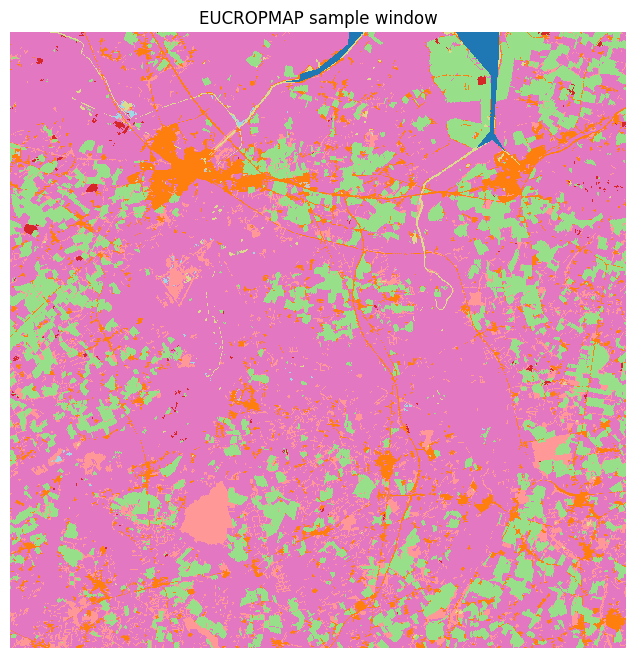

💾 Saved cropped GeoTIFF to: data/EU_crop_map_sample.tif
Top 5 codes by area: [500, 216, 300, 100, 211]

✅ Wrote updated table with feedstocks to data/processed/bipol_ranges_with_feedstocks.csv


Number of layers: 3

crop_code:
[216.0, 216.0, 500.0, 500.0, 216.0, 500.0, 211.0, 211.0, 500.0, 500.0] 

yield_kg_m2_year:
[2.5, 1.75, 2.5, 1.0, 2.5, 2.5, 1.75, 2.5, 1.75, 2.5] 

yield_kg_pixel_year:
[250.0, 250.0, 137.5, 212.5, 250.0, 250.0, 250.0, 250.0, 250.0, 212.5] 


✅ Wrote 3-band yield raster to data/processed/EU_crop_map_yield.tif



In [6]:
builder = FeedstockYieldMapBuilder(
    crop_raster_path="data/EU_crop_map.tif",
    sample_raster_path="data/EU_crop_map_sample.tif",
    biopol_ranges_csv="data/processed/biopol_ranges.csv",
    out_biopol_feedstocks_csv="data/processed/bipol_ranges_with_feedstocks.csv",
    out_yield_raster_path="data/processed/EU_crop_map_yield.tif",
    window_size=2000,
    n_top_codes=5,
    random_seed=42,
)

builder.run_all(visualize_sample=True)

### TravelDistanceCalculator() 
- take a factory location 
- draw a square around the location and calculate the sum of the materials you could collect in that square using an integral image 
- if the sum of materials is not enough, make the square larger, and vice versa, until you find the right size for the square 
- estimate the travel distances required for a truck to collect materials within that square, which is approximately 0.75 x radius 

In [7]:
import numpy as np
import pandas as pd
import rasterio


class TravelDistanceCalculator:
    """
    Fast travel-distance approximation around a supply grid using an integral image.

    The supply grid is assumed to be in kg/year per pixel (or any mass-per-pixel unit),
    and Q_required passed to `ton_km` should use the same mass unit.
    """

    # ---------- high-level constructors ----------

    @staticmethod
    def _build_supply_grids_from_tif(tif_path: str, feedstock_csv_path: str) -> dict[str, np.ndarray]:
        """
        Read EU_crop_map_yield.tif and build one supply grid per ingredient.

        Returns a dict:
            {feedstock_id: supply_grid_2d}

        where supply_grid_2d has units kg/year per pixel for that ingredient
        (0 where that ingredient is not present).
        """
        df = pd.read_csv(feedstock_csv_path)
        # expected columns: id, eu_crop_code, yield_kg_m2, ...

        with rasterio.open(tif_path) as src:
            # band 1 = crop_code
            # band 3 = yield_kg_pixel_year
            crop_code_band = src.read(1)
            yield_pixel_band = src.read(3)

        supply_grids: dict[str, np.ndarray] = {}
        for _, row in df.iterrows():
            code = row["eu_crop_code"]
            feedstock_id = row["id"]  # e.g. "f1", "f2", "b1", ...

            mask = (crop_code_band == code)
            grid = np.where(mask, yield_pixel_band, 0.0).astype("float32")

            supply_grids[feedstock_id] = grid

        return supply_grids

    @classmethod
    def from_tif(
        cls,
        tif_path: str,
        feedstock_csv_path: str,
        pixel_size_km: float,
        alpha: float = 0.75,
        max_radius_km: float | None = None,
    ) -> dict[str, "TravelDistanceCalculator"]:
        """
        Convenience constructor:
        - reads a 3-band yield raster + biopol feedstock table
        - builds one TravelDistanceCalculator per feedstock

        Returns:
            {feedstock_id: TravelDistanceCalculator}
        """
        supply_grids = cls._build_supply_grids_from_tif(tif_path, feedstock_csv_path)

        calculators: dict[str, TravelDistanceCalculator] = {}
        for feedstock_id, grid in supply_grids.items():
            calculators[feedstock_id] = cls(
                supply_grid=grid,
                pixel_size_km=pixel_size_km,
                alpha=alpha,
                max_radius_km=max_radius_km,
            )
        return calculators

    # ---------- per-grid calculator ----------

    def __init__(self, supply_grid, pixel_size_km=0.01, alpha=0.75, max_radius_km=None):
        """
        supply_grid : 2D array with mass per pixel (e.g. kg/year per pixel)
        pixel_size_km : size of one pixel in km
        alpha : factor for avg distance ~ alpha * R
        max_radius_km : optional cap on radius for search
        """
        self.supply_grid = np.asarray(supply_grid, dtype="float32")
        self.pixel_size_km = float(pixel_size_km)
        self.alpha = float(alpha)

        self.integral = self._compute_integral_image(self.supply_grid)
        self.max_radius_pixels = self._init_max_radius_pixels(max_radius_km)

    @staticmethod
    def _compute_integral_image(grid: np.ndarray) -> np.ndarray:
        """Build integral image for fast square window sums."""
        return grid.cumsum(axis=0).cumsum(axis=1)

    def _init_max_radius_pixels(self, max_radius_km: float | None) -> int:
        """Determine the maximum radius in pixels to search."""
        if max_radius_km is None:
            # default: allow up to the largest dimension
            return max(self.supply_grid.shape)
        return int(max_radius_km / self.pixel_size_km)

    # ---------- core helpers ----------

    def _square_sum(self, i: int, j: int, r: int) -> float:
        """Sum of supply in square window centred at (i,j) with half-size r (pixels)."""
        S = self.integral
        nrows, ncols = S.shape

        r0 = max(i - r, 0)
        c0 = max(j - r, 0)
        r1 = min(i + r, nrows - 1)
        c1 = min(j + r, ncols - 1)

        total = S[r1, c1]
        if r0 > 0:
            total -= S[r0 - 1, c1]
        if c0 > 0:
            total -= S[r1, c0 - 1]
        if r0 > 0 and c0 > 0:
            total += S[r0 - 1, c0 - 1]
        return float(total)

    def _radius_for_Q(self, i: int, j: int, Q_required: float) -> int | None:
        """
        Binary search for minimal radius (pixels) to collect at least Q_required
        units (same mass unit as supply_grid).
        """
        lo, hi = 0, self.max_radius_pixels

        # early check: even full radius cannot meet demand
        total_max = self._square_sum(i, j, hi)
        if total_max < Q_required:
            return None

        while lo < hi:
            mid = (lo + hi) // 2
            total = self._square_sum(i, j, mid)
            if total >= Q_required:
                hi = mid
            else:
                lo = mid + 1

        return lo  # pixels

    # ---------- public API ----------

    def ton_km(self, i: int, j: int, Q_required_kg: float) -> float:
        """
        Estimate total mass-distance (ton-km) needed to collect Q_required_kg
        from around pixel (i, j).

        Assumes:
        - supply_grid is in kg per pixel
        - pixel_size_km is in km
        - alpha ≈ factor to approximate average distance ~ alpha * R

        Returns:
            ton_km (float), with mass converted from kg to tonnes.
        """
        r_pixels = self._radius_for_Q(i, j, Q_required_kg)
        if r_pixels is None:
            return np.inf

        R_km = r_pixels * self.pixel_size_km
        avg_distance_km = self.alpha * R_km

        Q_ton = Q_required_kg / 1000.0
        ton_km = Q_ton * avg_distance_km
        return ton_km


#### Implementation

In [8]:
tif_path = "data/processed/EU_crop_map_yield.tif"
feedstock_csv_path = "data/processed/bipol_ranges_with_feedstocks.csv"

travel_calculators_dict = TravelDistanceCalculator.from_tif(
    tif_path=tif_path,
    feedstock_csv_path=feedstock_csv_path,
    pixel_size_km=10 / 1000,  # 10 m pixels
    alpha=0.75,
    max_radius_km=None,       # or set a cap
)

ingredient_requirement_dict = {
    'f1': 600, # bark
    'f2': 0, # seagrass
    'f3': 0, # hemp 
    'b1': 400, # pea protein
    'b2': 0, # xanthan gum 
}

max_i = next(iter(travel_calculators_dict.values())).supply_grid.shape[0]
max_j = next(iter(travel_calculators_dict.values())).supply_grid.shape[1]
import random 
i = random.randint(0, max_i)
j = random.randint(0, max_j)

total_travel_distance = 0 
for id, kg_required in ingredient_requirement_dict.items(): 
    travel_distance = travel_calculators_dict[id].ton_km(i, j, kg_required)
    total_travel_distance = total_travel_distance + travel_distance
    print(f'travel distance required for {id}: {travel_distance}')

travel distance required for f1: 0.20700000000000002
travel distance required for f2: 0.0
travel distance required for f3: 0.0
travel distance required for b1: 0.087
travel distance required for b2: 0.0


## 4. Optimization

### AdaaptiveFactoryModel() class

In [9]:
class AdaptiveFactoryModel: 
    def __init__(self, ingredient_requirement_dict): 
        self.ingredient_requirement_dict = ingredient_requirement_dict # dictionary of ingredient requirements {'name': amount}
        self.lca = PanelProductionLCA() # make lca object with unit impact of panel production 
        self.travel_calculators_dict = TravelDistanceCalculator.from_tif(
                tif_path="data/processed/EU_crop_map_yield.tif",
                feedstock_csv_path="data/processed/bipol_ranges_with_feedstocks.csv",
                pixel_size_km=10 / 1000, # 10 m pixels
                alpha=0.75, # TODO: what's alpha? need to check
                max_radius_km=None, # or set a cap
            )

    def __getstate__(self):
        """Control what gets pickled (for deepcopy/history)."""
        state = self.__dict__.copy()
        # Drop the heavy / non-picklable LCA object from the *copied* state
        if "lca" in state:
            state["lca"] = None
        return state

    def __setstate__(self, state):
        """Restore from pickled state (used for history copies)."""
        self.__dict__.update(state)
        # We *don’t* recreate self.lca here on purpose.
        # History snapshots won’t be used for evaluation.

    def run(self, i, j): 
        travel_distance = self.calculate_travel_distance(i, j) 
        self.calculate_environmental_impact(travel_distance)
    
    def calculate_travel_distance(self, i, j): 
        total_travel_distance = 0 
        for id, kg_required in self.ingredient_requirement_dict.items(): 
            travel_distance = self.travel_calculators_dict[id].ton_km(i, j, kg_required)
            total_travel_distance = total_travel_distance + travel_distance
        return total_travel_distance 
    
    def calculate_environmental_impact(self, travel_distance): 
        result_df = self.lca.evaluate(
            b1_pea_protein = self.ingredient_requirement_dict['b1'],
            b2_xanthan_gum = self.ingredient_requirement_dict['b2'],
            f1_bark = self.ingredient_requirement_dict['f1'],
            f2_seagrass = self.ingredient_requirement_dict['f2'],
            f3_hemp = self.ingredient_requirement_dict['f3'],
            transport_ton_km_per_kg = travel_distance,
            save_excel = False,  # probably False inside optimization
        )
        self.impact_gwp100 = result_df['panel_impacts'].GWP100.sum() 

#### Implementation

In [10]:
# initiate model outside of optimization 
# takes ~ 30 seconds because pa-LCA setup takes a while
ingredient_requirement_dict = {'f1': 600, 'f2': 0, 'f3': 500, 'b1': 400, 'b2': 300}
model = AdaptiveFactoryModel(ingredient_requirement_dict)

In [11]:
# calculate impact inside of optimization 
import random 
i, j = random.randint(0, 2000), random.randint(0, 2000)
model.run(i, j)
model.impact_gwp100

1.9274935420647492

### Single objective optimization 

In [12]:
# create model - run only once, this takes ~30 seconds 
ingredient_requirement_dict = {'f1': 600, 'f2': 0, 'f3': 500, 'b1': 400, 'b2': 300}
model = AdaptiveFactoryModel(ingredient_requirement_dict)

In [13]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.optimize import minimize 
import rasterio

# define bounds for coordinates (these are not xy coordinates, but ij indexes)
grid = next(iter(model.travel_calculators_dict.values())).supply_grid
low_bounds = [0, 0]
high_bounds = [grid.shape[0] - 1, grid.shape[1] - 1]   # max valid index is dim-1

# define optimization problem 
class Single(ElementwiseProblem):
    def __init__(self, model):
        self.model = model
        super().__init__(
            n_var=2,              # two decision variables: x and y
            n_obj=1,              # single objective
            xl=low_bounds,        # lower bounds
            xu=high_bounds,       # upper bounds
            elementwise_evaluation=True
        )

    def _evaluate(self, x, out, *args, **kwargs):

        loc_i = int(x[0])
        loc_j = int(x[1])

        try:
            self.model.run(i=loc_i, j=loc_j)
            objective_value = model.impact_gwp100
        except Exception as e:
            # Handle invalid areas (e.g. outside raster)
            print(f"Warning: evaluation failed at ({loc_i}, {loc_j}): {e}")
            objective_value = np.inf

        out["F"] = objective_value


# run optimization 
problem = Single(model)
algorithm = GA(pop_size=50)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 10),
    seed=42,
    verbose=True,
    save_history=True,  
)

# 5. Inspect results
print("\nBest factory location:")
print(f"x: {res.X[0]:.2f}, y: {res.X[1]:.2f}")
print(f"Objective value: {res.F[0]:.2f}")

n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       50 |  1.9338320648 |  1.8770492883
     2 |      100 |  1.8899306648 |  1.8700254048
     3 |      150 |  1.8821320257 |  1.8630015214
     4 |      200 |  1.8776665386 |  1.8630015214
     5 |      250 |  1.8740226330 |  1.8598088471
     6 |      300 |  1.8725710305 |  1.8598088471
     7 |      350 |  1.8702339929 |  1.8598088471
     8 |      400 |  1.8683652142 |  1.8587446223
     9 |      450 |  1.8672626773 |  1.8587446223
    10 |      500 |  1.8667135374 |  1.8587446223

Best factory location:
x: 1563.27, y: 75.15
Objective value: 1.86


#### Visualize

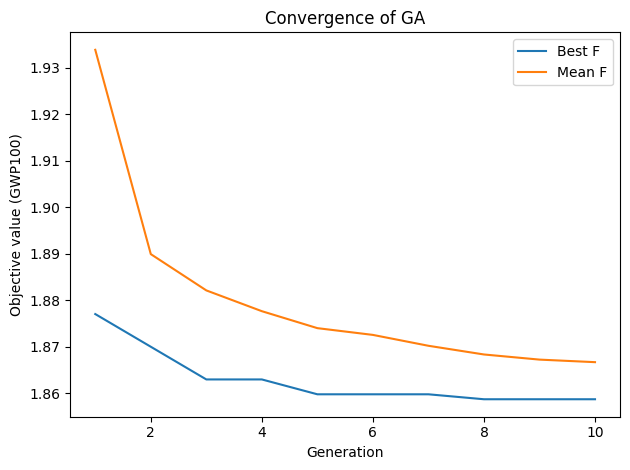

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# assuming `res` comes from pymoo.optimize.minimize(...)
best_F = []
mean_F = []

for algo in res.history:
    pop_F = algo.pop.get("F")  # objective values for this generation
    best_F.append(pop_F.min())
    mean_F.append(pop_F.mean())

generations = np.arange(1, len(best_F) + 1)

plt.figure()
plt.plot(generations, best_F, label="Best F")
plt.plot(generations, mean_F, label="Mean F")
plt.xlabel("Generation")
plt.ylabel("Objective value (GWP100)")
plt.title("Convergence of GA")
plt.legend()
plt.tight_layout()
plt.show()


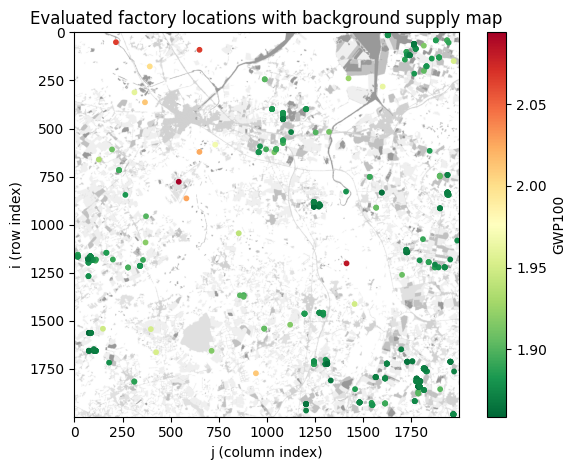

In [15]:
import numpy as np
import matplotlib.pyplot as plt

X_all = []
F_all = []

for algo in res.history:
    pop = algo.pop
    X = pop.get("X")
    F = pop.get("F")
    X_all.append(X)
    F_all.append(F)

X_all = np.vstack(X_all)
F_all = np.vstack(F_all).ravel()

i_vals = X_all[:, 0]
j_vals = X_all[:, 1]

# ---- Background grid ----
grids = [tc.supply_grid for tc in model.travel_calculators_dict.values()]
bg_grid = np.sum(grids, axis=0)

# lock color scaling
vmin = bg_grid.min()
vmax = bg_grid.max()

plt.figure()

# ---- Background ----
plt.imshow(
    bg_grid,
    origin="upper",   # this ensures index 0 is at the TOP
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
    alpha=0.4
)

# ---- Scatter points ----
sc = plt.scatter(
    j_vals,
    i_vals,
    c=F_all,
    s=10,
    cmap="RdYlGn_r"
)

# ❌ REMOVE invert_yaxis()
# plt.gca().invert_yaxis()   # remove this line

plt.xlabel("j (column index)")
plt.ylabel("i (row index)")
plt.title("Evaluated factory locations with background supply map")

plt.colorbar(sc, label="GWP100")
plt.tight_layout()
plt.show()


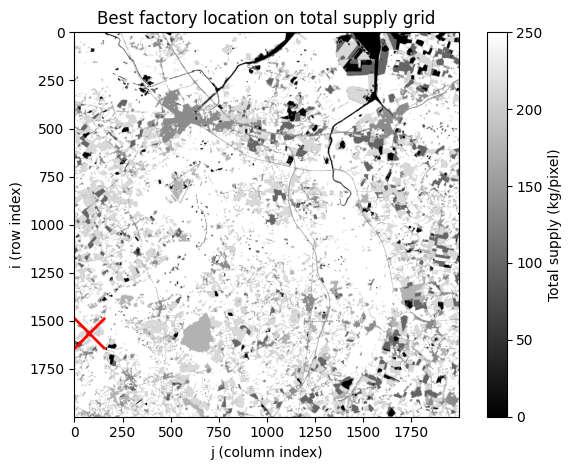

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Best solution
best_i = int(round(res.X[0]))
best_j = int(round(res.X[1]))

# 2. Sum of all supply grids
grids = [tc.supply_grid for tc in model.travel_calculators_dict.values()]
grid_sum = np.sum(grids, axis=0)

# 3. Lock color scaling so map == colorbar
vmin = grid_sum.min()
vmax = grid_sum.max()

plt.figure()

# Background in grayscale with fixed limits
im = plt.imshow(
    grid_sum,
    origin="upper",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

# Red, large X for factory location
plt.scatter(
    best_j,
    best_i,
    marker="x",
    s=500,
    color="red",
    linewidths=2
)

plt.title("Best factory location on total supply grid")
plt.xlabel("j (column index)")
plt.ylabel("i (row index)")

plt.colorbar(im, label="Total supply (kg/pixel)")
plt.tight_layout()
plt.show()


/var/folders/jy/n4b2f9d16xbckrmnhmlqjc1w0000gq/T/ipykernel_61161/1011761000.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab10", len(material_names))


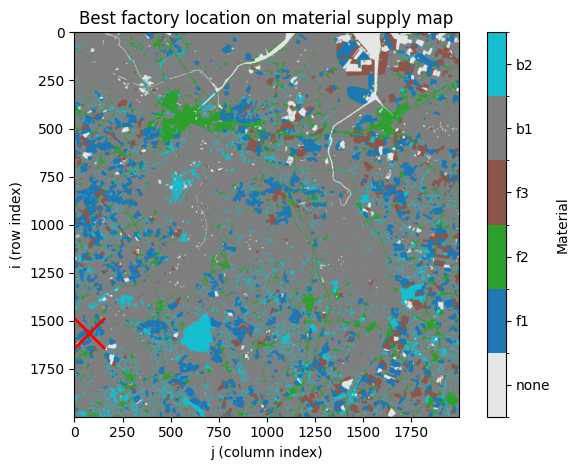

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1. Best solution
best_i = int(round(res.X[0]))
best_j = int(round(res.X[1]))

# 2. Get material names and grids (one per material)
material_names = list(model.travel_calculators_dict.keys())
tcs = list(model.travel_calculators_dict.values())
grids = [tc.supply_grid for tc in tcs]   # list of 2D arrays

# Stack into (n_materials, H, W)
stack = np.stack(grids, axis=0)

# 3. Build a "material index" grid
#    0 = no material, 1..N = each material index
has_supply = stack > 0
any_supply = has_supply.any(axis=0)                # (H, W), True if any material there
material_idx_raw = np.argmax(has_supply, axis=0)   # 0..N-1, but meaningless where all False

material_grid = np.zeros_like(material_idx_raw, dtype=int)
material_grid[any_supply] = material_idx_raw[any_supply] + 1   # 1..N where supply exists

# 4. Build a discrete colormap: first color = "no material"
base_cmap = plt.cm.get_cmap("tab10", len(material_names))
colors = [(0.9, 0.9, 0.9, 1.0)]  # light gray for "no material"
colors += [base_cmap(i) for i in range(len(material_names))]
cmap = ListedColormap(colors)

# Boundaries so each integer gets its own color band
bounds = np.arange(-0.5, len(material_names) + 1.5)
norm = BoundaryNorm(bounds, cmap.N)

plt.figure()

# Background: categorical material map
im = plt.imshow(
    material_grid,
    origin="upper",
    cmap=cmap,
    norm=norm
)

# Red, large X for factory location
plt.scatter(
    best_j,
    best_i,
    marker="x",
    s=500,
    color="red",
    linewidths=2
)

plt.title("Best factory location on material supply map")
plt.xlabel("j (column index)")
plt.ylabel("i (row index)")

# Colorbar with material names
cbar = plt.colorbar(im, ticks=np.arange(0, len(material_names) + 1))
cbar_labels = ["none"] + material_names
cbar.ax.set_yticklabels(cbar_labels)
cbar.set_label("Material")

plt.tight_layout()
plt.show()


### Multi objective optimization (not started)

In [18]:
# class Multi(ElementwiseProblem):
#     def __init__(self):
#         super().__init__(
#             n_var=6,
#             n_obj=2,
#             n_constr=0,
#             xl=low_bounds,
#             xu=high_bounds,
#             elementwise_evaluation=True
#         )

#     def _evaluate(self, x, out, *args, **kwargs):

#         b1_pea_protein, b2_xanthan_gum, b3_soy_resin_mass, f1_bark, f2_seagrass, f3_hemp = [np.array([value]).reshape((1,1)) for value in x]

#         F = model(b1_pea_protein, b2_xanthan_gum, b3_soy_resin_mass, f1_bark, f2_seagrass, f3_hemp)

#         out["F"] = F[0, :2]

# mo_problem = Multi()
# mo_algo    = NSGA2(pop_size=100)
# mo_res     = minimize(
#     mo_problem,
#     mo_algo,
#     ('n_gen', 200),
#     seed=42,
#     verbose=True
# )